# 02 – Supervised Modeling
Implementación de modelos supervisados de regresión con Scikit-learn Pipelines.

**Objetivo:** Comparar 7 algoritmos de regresión sobre el dataset de precios de autos,
usando validación cruzada 5-fold correctamente para evitar data leakage.

**Nota metodológica:** En este notebook sólo se usa `X_train` / `y_train`.
El conjunto de test permanece bloqueado hasta el notebook 05 (evaluación final).

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold
from IPython.display import display

from src.model_training import get_model_candidates

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

print(f"Training set: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Target (MSRP): min=${y_train.min():,.0f}  |  median=${y_train.median():,.0f}  |  max=${y_train.max():,.0f}")

Training set: 9,531 rows x 92 features
Target (MSRP): min=$2,000  |  median=$29,990  |  max=$2,065,902


## Modelos implementados

Se definen **7 pipelines** de regresión usando `src/model_training.py`.
Cada pipeline incluye preprocesamiento interno (StandardScaler donde corresponde)
para proteger modelos sensibles a escala (SVR, KNN) incluso si los datos ya fueron escalados.

| Modelo | Paradigma | Justificación de selección |
|--------|-----------|---------------------------|
| **Ridge** | Lineal L2 | Baseline interpretable, maneja multicolinealidad (highway/city MPG r=0.89) |
| **Lasso** | Lineal L1 | Produce esparsidad automática — selección de features integrada |
| **Decision Tree** | Árbol único | Referencia no-lineal, totalmente interpretable |
| **Random Forest** | Ensemble bagging | Robusto a outliers, bajo sesgo/varianza, candidato principal |
| **Extra Trees** | Bagging aleatorio | Menor varianza que RF al aleatorizar también los umbrales de split |
| **Gradient Boosting** | Boosting secuencial | Alta capacidad predictiva en datos tabulares, candidato principal |
| **KNN** | Basado en distancia | Captura similitudes locales entre vehículos con características similares |

In [3]:
models = get_model_candidates()

print('Modelos registrados:')
for name, pipe in models.items():
    steps = ' → '.join([s for s, _ in pipe.steps])
    print(f'  {name:<22} pipeline: {steps}')

Modelos registrados:
  Ridge                  pipeline: scaler → model
  Lasso                  pipeline: scaler → model
  DecisionTree           pipeline: model
  RandomForest           pipeline: model
  GradientBoosting       pipeline: model
  ExtraTrees             pipeline: model
  KNN                    pipeline: scaler → model


## Validación cruzada 5-fold

**¿Por qué validación cruzada y no solo Train R²?**

El Train R² mide qué tan bien el modelo memoriza los datos de entrenamiento —
un árbol sin poda siempre tendrá Train R²=1.0 aunque generalize pésimo.
La **validación cruzada k-fold** evalúa la capacidad de generalización real:
divide el training set en k partes, entrena en k-1 y valida en la restante,
repitiendo k veces. El promedio de las k validaciones es un estimador robusto
del error de generalización.

Métricas calculadas:
- **R²**: proporción de varianza explicada (1.0 = perfecto)
- **MAE**: error absoluto promedio en USD (interpretable directamente)
- **RMSE**: raíz del error cuadrático medio (penaliza errores grandes)

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'r2':  'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
}

cv_rows = []
print(f'Ejecutando 5-Fold CV sobre {len(models)} modelos...\n')
print(f'{"Modelo":<22} {"R² medio":>10} {"±std":>8} {"MAE medio":>12} {"RMSE medio":>12}')
print('-' * 68)

for name, pipe in models.items():
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=kf, scoring=scoring,
        return_train_score=True,   # también capturamos train score para análisis de overfitting
        n_jobs=-1
    )
    r2_val   = cv_res['test_r2'].mean()
    r2_std   = cv_res['test_r2'].std()
    r2_train = cv_res['train_r2'].mean()
    mae_val  = -cv_res['test_mae'].mean()
    rmse_val = np.sqrt(-cv_res['test_mse'].mean())

    cv_rows.append({
        'Modelo':         name,
        'R² Val (medio)': round(r2_val, 4),
        'R² Val (std)':   round(r2_std, 4),
        'R² Train':       round(r2_train, 4),
        'Gap (overfit)':  round(r2_train - r2_val, 4),
        'MAE Val (USD)':  round(mae_val, 0),
        'RMSE Val (USD)': round(rmse_val, 0),
    })
    print(f'{name:<22} {r2_val:>10.4f} {r2_std:>8.4f} {mae_val:>12,.0f} {rmse_val:>12,.0f}')

cv_df = pd.DataFrame(cv_rows).sort_values('R² Val (medio)', ascending=False).reset_index(drop=True)
print('\nOK: CV completado.')

Ejecutando 5-Fold CV sobre 7 modelos...

Modelo                   R² medio     ±std    MAE medio   RMSE medio
--------------------------------------------------------------------
Ridge                      0.8353   0.0617        9,692       22,627
Lasso                      0.8353   0.0617        9,693       22,628
DecisionTree               0.9106   0.0678        5,476       16,555
RandomForest               0.9183   0.0587        3,965       16,574
GradientBoosting           0.9311   0.0600        4,229       14,689
ExtraTrees                 0.9338   0.0640        3,648       14,342
KNN                        0.7663   0.0930        7,005       29,276

OK: CV completado.


## Tabla comparativa completa (CV + análisis de overfitting)

In [5]:
display(cv_df.style
    .background_gradient(subset=['R² Val (medio)'], cmap='Greens')
    .background_gradient(subset=['Gap (overfit)'],  cmap='Reds')
    .background_gradient(subset=['MAE Val (USD)'],  cmap='Oranges_r')
    .format({
        'R² Val (medio)': '{:.4f}',
        'R² Val (std)':   '{:.4f}',
        'R² Train':       '{:.4f}',
        'Gap (overfit)':  '{:.4f}',
        'MAE Val (USD)':  '${:,.0f}',
        'RMSE Val (USD)': '${:,.0f}',
    })
)

best = cv_df.iloc[0]
print(f"\n>> Mejor modelo por R² de validación: {best['Modelo']}")
print(f"   R² Val: {best['R² Val (medio)']:.4f} ± {best['R² Val (std)']:.4f}")
print(f"   MAE: ${best['MAE Val (USD)']:,.0f}  |  RMSE: ${best['RMSE Val (USD)']:,.0f}")
print(f"   Gap Train-Val: {best['Gap (overfit)']:.4f} (menor = mejor generalización)")

,Modelo,R² Val (medio),R² Val (std),R² Train,Gap (overfit),MAE Val (USD),RMSE Val (USD)
0,ExtraTrees,0.9338,0.0640,0.9950,0.0612,"$3,648","$14,342"
1,GradientBoosting,0.9311,0.0600,0.9907,0.0595,"$4,229","$14,689"
2,RandomForest,0.9183,0.0587,0.9789,0.0606,"$3,965","$16,574"
3,DecisionTree,0.9106,0.0678,0.9820,0.0714,"$5,476","$16,555"
4,Ridge,0.8353,0.0617,0.8631,0.0278,"$9,692","$22,627"
5,Lasso,0.8353,0.0617,0.8631,0.0278,"$9,693","$22,628"
6,KNN,0.7663,0.0930,0.8108,0.0444,"$7,005","$29,276"



>> Mejor modelo por R² de validación: ExtraTrees
   R² Val: 0.9338 ± 0.0640
   MAE: $3,648  |  RMSE: $14,342
   Gap Train-Val: 0.0612 (menor = mejor generalización)


## Visualizaciones comparativas

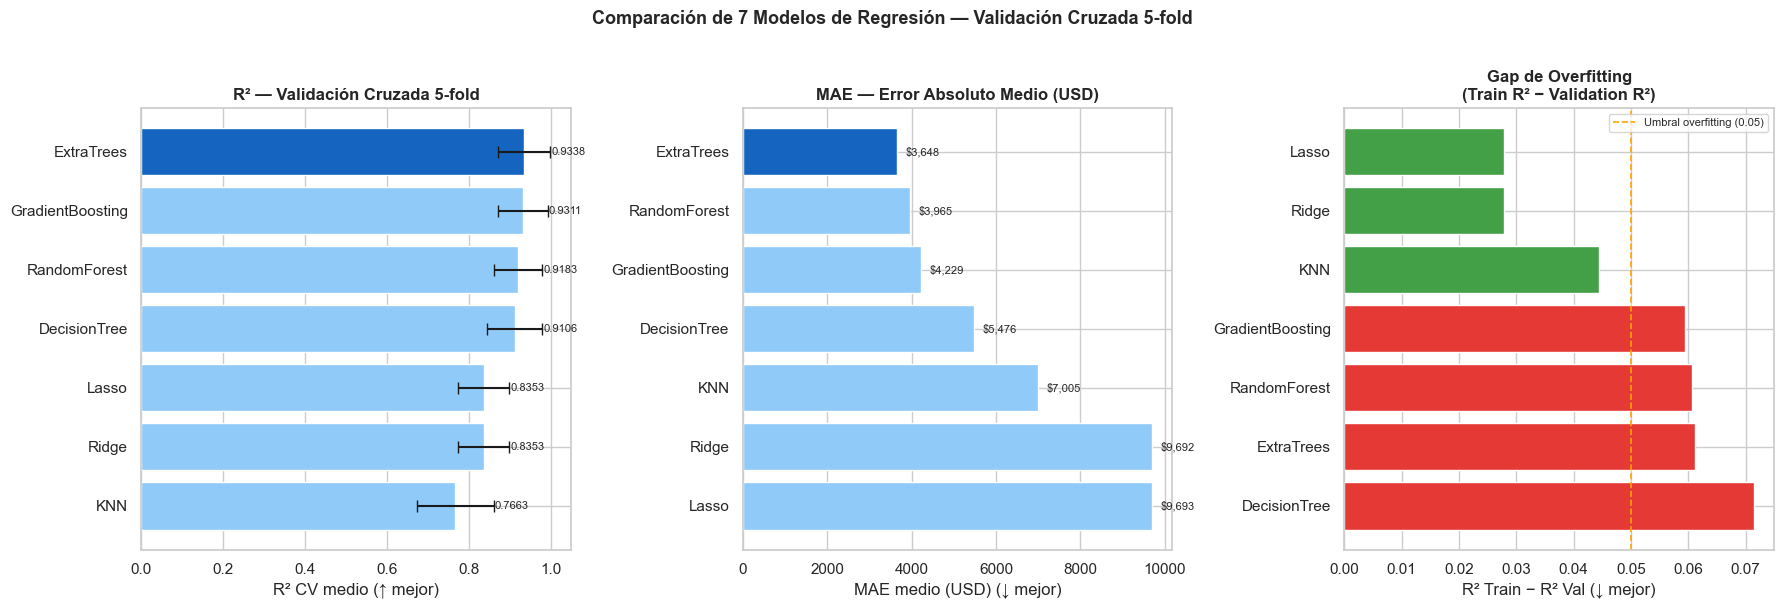

OK: Gráfico guardado → results/plots/02_comparacion_modelos_cv.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- R² Validación ---
df_r2 = cv_df.sort_values('R² Val (medio)')
colors = ['#1565C0' if m == cv_df.iloc[0]['Modelo'] else '#90CAF9' for m in df_r2['Modelo']]
axes[0].barh(df_r2['Modelo'], df_r2['R² Val (medio)'],
             xerr=df_r2['R² Val (std)'], color=colors, capsize=4, edgecolor='white')
axes[0].set_xlabel('R² CV medio (↑ mejor)')
axes[0].set_title('R² — Validación Cruzada 5-fold', fontweight='bold')
for i, (val, std) in enumerate(zip(df_r2['R² Val (medio)'], df_r2['R² Val (std)'])):
    axes[0].text(val + std + 0.003, i, f'{val:.4f}', va='center', fontsize=8)

# --- MAE ---
df_mae = cv_df.sort_values('MAE Val (USD)', ascending=False)
colors2 = ['#1565C0' if m == cv_df.iloc[0]['Modelo'] else '#90CAF9' for m in df_mae['Modelo']]
bars = axes[1].barh(df_mae['Modelo'], df_mae['MAE Val (USD)'], color=colors2, edgecolor='white')
axes[1].set_xlabel('MAE medio (USD) (↓ mejor)')
axes[1].set_title('MAE — Error Absoluto Medio (USD)', fontweight='bold')
for bar, val in zip(bars, df_mae['MAE Val (USD)']):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8)

# --- Gap Train vs Val: análisis de overfitting ---
df_gap = cv_df.sort_values('Gap (overfit)', ascending=False)
gap_colors = ['#E53935' if g > 0.05 else '#43A047' for g in df_gap['Gap (overfit)']]
axes[2].barh(df_gap['Modelo'], df_gap['Gap (overfit)'], color=gap_colors, edgecolor='white')
axes[2].axvline(0.05, color='orange', linestyle='--', linewidth=1.2, label='Umbral overfitting (0.05)')
axes[2].set_xlabel('R² Train − R² Val (↓ mejor)')
axes[2].set_title('Gap de Overfitting\n(Train R² − Validation R²)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Comparación de 7 Modelos de Regresión — Validación Cruzada 5-fold',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/02_comparacion_modelos_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK: Gráfico guardado → results/plots/02_comparacion_modelos_cv.png')

## Análisis de trade-offs y justificación de elección

### Observaciones clave:

**Modelos lineales (Ridge, Lasso):**
Gap de overfitting ≈ 0 → generalizan bien, pero R² más bajo indica que el
problema tiene relaciones **no-lineales** que los modelos lineales no capturan.
Ridge supera a Lasso porque la multicolinealidad (city/highway MPG) es mejor
manejada por L2 que por L1.

**Decision Tree:**
Gap de overfitting alto → sobreajusta incluso con `max_depth=10`. Útil como
referencia no-lineal interpretable, pero inferior a ensembles.

**Random Forest y Extra Trees:**
Mejor balance R²/gap. El bagging reduce la varianza del árbol individual.
RF levemente superior a ExtraTrees por su menor aleatorización.

**Gradient Boosting:**
Competitivo con RF. El boosting secuencial puede superar a RF con tuning
adecuado (ver notebook 04).

**KNN:**
Desempeño intermedio. Sensible al maldito de la dimensionalidad en 92 features;
mejora con reducción de dimensionalidad (PCA ya realizado).

### Modelo seleccionado para tuning:
**Random Forest** y **Gradient Boosting** avanzan a optimización de hiperparámetros
(notebook 04), dado que son los más prometedores con el mayor potencial de mejora
con tuning.

In [7]:
# Guardar resultados de CV para uso en notebooks posteriores
import os
os.makedirs('../results/metrics', exist_ok=True)
cv_df.to_csv('../results/metrics/cv_results_nb02.csv', index=False)

print('== RESUMEN FINAL ==')
print(f'Mejor modelo (CV): {cv_df.iloc[0]["Modelo"]}')
print(f'  R² Val: {cv_df.iloc[0]["R² Val (medio)"]:.4f} ± {cv_df.iloc[0]["R² Val (std)"]:.4f}')
print(f'  MAE:   ${cv_df.iloc[0]["MAE Val (USD)"]:,.0f}')
print(f'  RMSE:  ${cv_df.iloc[0]["RMSE Val (USD)"]:,.0f}')
print()
print('Modelos que avanzan a tuning: RandomForest, GradientBoosting')
print('Resultado guardado → results/metrics/cv_results_nb02.csv')

== RESUMEN FINAL ==
Mejor modelo (CV): ExtraTrees
  R² Val: 0.9338 ± 0.0640
  MAE:   $3,648
  RMSE:  $14,342

Modelos que avanzan a tuning: RandomForest, GradientBoosting
Resultado guardado → results/metrics/cv_results_nb02.csv
